<a href="https://colab.research.google.com/github/SunitaJakhar/Data-Cleaning-to-ML-Models-Classification-Regression-Pipeline/blob/main/Set_Exercise_Training_data_science_skills_From_data_cleaning_to_a_machine_learning_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1: DATA LOADING, PREPROCESSING AND EDA

1.1. Data Loading and Initial Inspection

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np

In [ ]:
# Load the dataset
df = pd.read_csv('/content/Task 1 & 2 - Data_Feb_2026.csv')

In [ ]:
# Display the first 5 rows of the DataFrame
df.head()

,X1,X2,X3,X4,Label
0,3.62160,8.6661,-2.8073,-0.44699,0.0
1,4.54590,8.1674,-2.4586,-1.46210,0.0
2,3.86600,-2.6383,1.9242,0.10645,0.0
3,3.45660,9.5228,-4.0112,-3.59440,0.0
4,0.32924,-4.4552,4.5718,-0.98880,0.0


In [ ]:
# Display Data Type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1375 entries, 0 to 1374
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1375 non-null   float64
 1   X2      1375 non-null   float64
 2   X3      1375 non-null   float64
 3   X4      1375 non-null   float64
 4   Label   1374 non-null   float64
dtypes: float64(5)
memory usage: 53.8 KB


In [ ]:
# Statistical distribution of each numerical feature
df.describe()

,X1,X2,X3,X4,Label
count,1375.000000,1375.000000,1375.000000,1375.000000,1374.000000
mean,0.386657,2.014202,1.359162,-1.250522,0.443959
std,3.418977,6.676094,4.527056,2.987968,0.497030
min,-70.000000,-13.773100,-50.000000,-80.000000,0.000000
25%,-1.774700,-1.697850,-1.630450,-2.428000,0.000000
50%,0.496650,2.325900,0.616630,-0.586650,0.000000
75%,2.822050,6.819300,3.181600,0.394810,1.000000
max,6.824800,120.000000,17.927400,2.449500,1.000000


1.2. Data Cleaning and Preprocessing Steps

In [ ]:
# To check Null values
df.isnull().sum()

,0
X1,0
X2,0
X3,0
X4,0
Label,1


In [ ]:
# Check for duplicates
duplicates = df[df.duplicated()]

# Display the number of duplicate rows
print(f"Number of duplicate rows: {duplicates.shape[0]}")

Number of duplicate rows: 25


In [ ]:
# Remove duplicate rows, if any
df_cleaned = df.drop_duplicates()

# Display the new shape of the dataset after removing duplicates
print(f"Dataset after removing duplicates contains {df_cleaned.shape[0]} rows.")

Dataset after removing duplicates contains 1350 rows.


In [ ]:
# Detect outliers using IQR
numerical_cols = df.select_dtypes(include=[np.number]).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers detected")

X1: 1 outliers detected
X2: 1 outliers detected
X3: 57 outliers detected
X4: 34 outliers detected
Label: 0 outliers detected


In [ ]:
# Capping Outliers (Winsorization) - Using this to keep all records but reduce the influence of extreme values

df_capped = df.copy()
for col in numerical_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_capped[col] = df_capped[col].clip(lower=lower_bound,
                                         upper=upper_bound)
print("Outliers have been capped.")

Outliers have been capped.


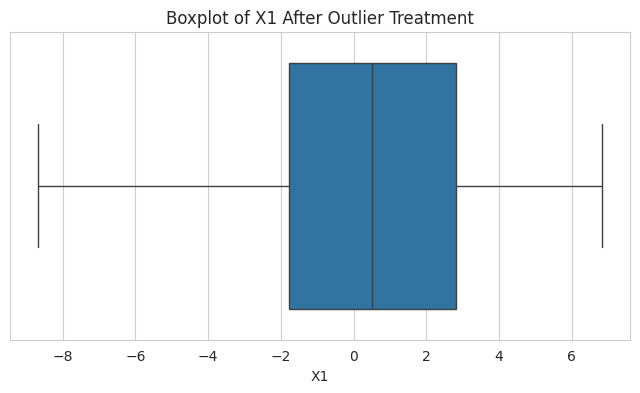

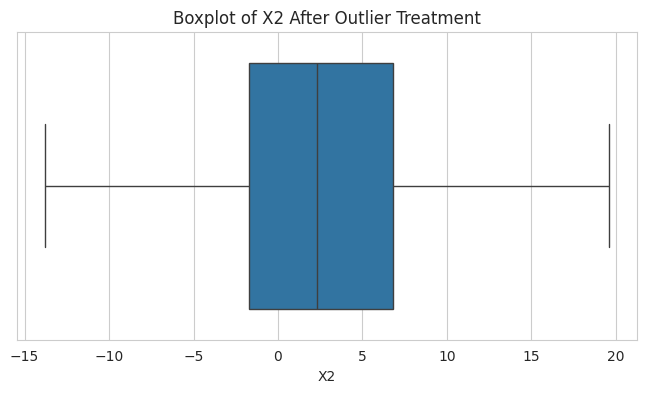

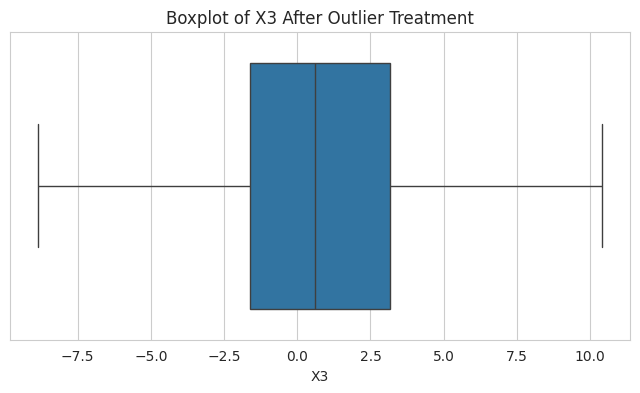

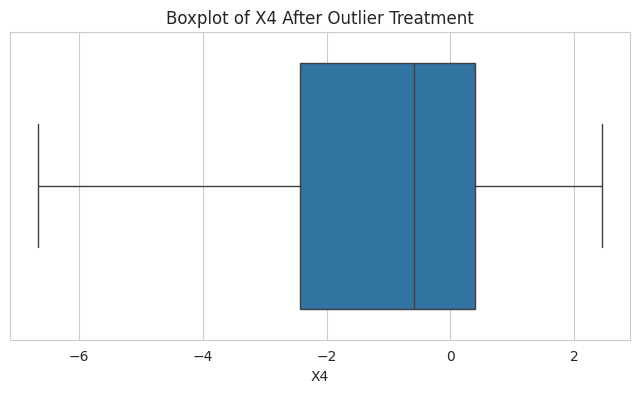

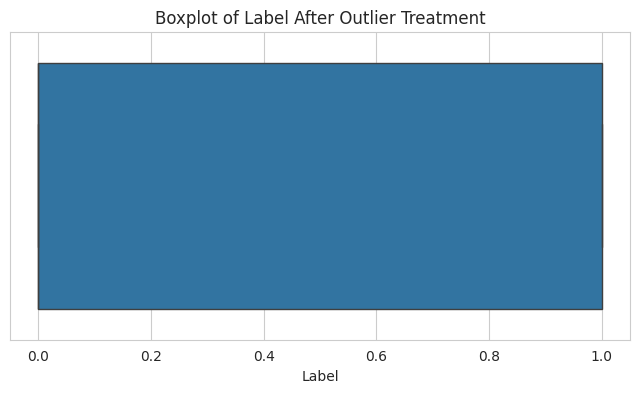

In [ ]:
# Verify the Treatment with New Boxplots

import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_capped[col])  # or df_removed[col]
    plt.title(f'Boxplot of {col} After Outlier Treatment')
    plt.show()

1.3. Exploratory Data Analysis (EDA)

In [ ]:
# Descriptive statistics after preprocessing and cleaning

print("\nDataFrame after outlier handling:")
display(df_capped.describe())


DataFrame after outlier handling:


,X1,X2,X3,X4,Label
count,1375.000000,1375.000000,1375.000000,1375.000000,1374.000000
mean,0.431261,1.941181,1.268038,-1.182043,0.443959
std,2.853309,5.887136,3.981657,2.062333,0.497030
min,-8.669825,-13.773100,-8.848525,-6.662215,0.000000
25%,-1.774700,-1.697850,-1.630450,-2.428000,0.000000
50%,0.496650,2.325900,0.616630,-0.586650,0.000000
75%,2.822050,6.819300,3.181600,0.394810,1.000000
max,6.824800,19.595025,10.399675,2.449500,1.000000


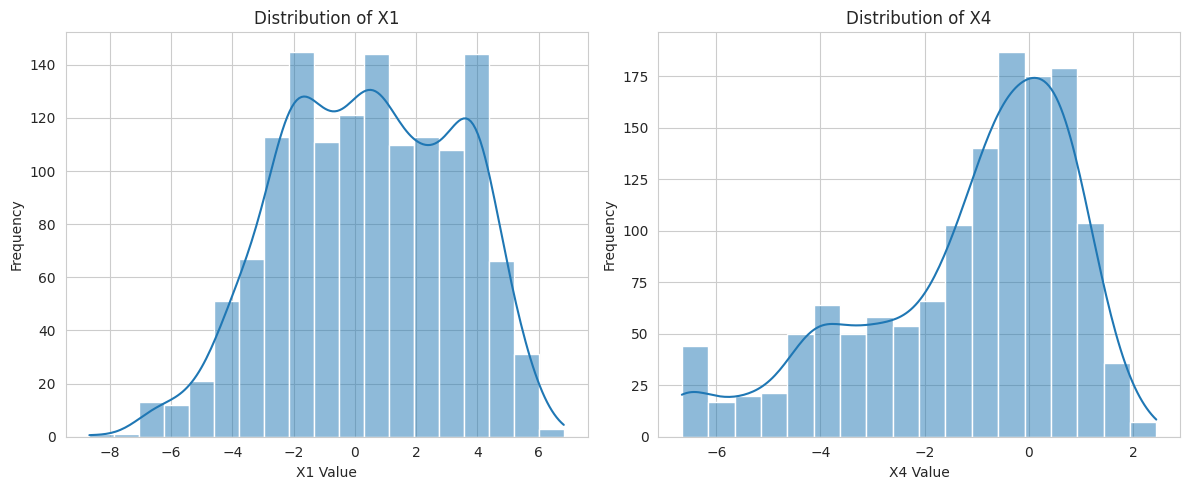

In [ ]:
# Visualisation - Distributions of features X1 and X4

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_capped['X1'], kde=True)
plt.title('Distribution of X1')
plt.xlabel('X1 Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df_capped['X4'], kde=True)
plt.title('Distribution of X4')
plt.xlabel('X4 Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
x1_mean = df_capped['X1'].mean()
x4_mean = df_capped['X4'].mean()

print(f"Mean of X1: {x1_mean:.2f}")
print(f"Mean of X4: {x4_mean:.2f}")

print("\nOne key difference is that the mean of X1 is positive, while the mean of X4 is negative, indicating that, on average, X1 values are higher than X4 values.")

Mean of X1: 0.43
Mean of X4: -1.18

One key difference is that the mean of X1 is positive, while the mean of X4 is negative, indicating that, on average, X1 values are higher than X4 values.


As observed, the mean of X1 is 0.43, while the mean of X4 is -1.18. This indicates a key difference: the mean of X1 is positive, while the mean of X4 is negative, suggesting that, on average, X1 values are higher than X4 values.

## Task 2: Probability, Gini Impurity, Entropy, and Misclassification Rate

In [ ]:
# Total number of records
total_records = len(df_capped)

# Count occurrences of each class
label_counts = df_capped['Label'].value_counts()

# Number of class 0 and class 1 records
count_0 = label_counts.get(0, 0)
count_1 = label_counts.get(1, 0)

# Calculate probabilities
p0 = count_0 / total_records
p1 = count_1 / total_records

print("Probability of Class 0:", round(p0, 4))
print("Probability of Class 1:", round(p1, 4))

Probability of Class 0: 0.5556
Probability of Class 1: 0.4436


In [ ]:
# Compute Gini impurity - Formula: 1 - (p0² + p1²)
gini_impurity = 1 - (p0**2 + p1**2)
print("\nGini Impurity:", round(gini_impurity, 4))


Gini Impurity: 0.4945


In [ ]:
# Compute Entropy - Formula: -(p0*log2(p0) + p1*log2(p1))
entropy = 0

if p0 > 0:
    entropy -= p0 * np.log2(p0)

if p1 > 0:
    entropy -= p1 * np.log2(p1)

print("Entropy of the dataset:", round(entropy, 4))

Entropy of the dataset: 0.9912


In [ ]:
# Misclassification Rate - Formula: 1 - max(p0, p1)
misclassification_rate = 1 - max(p0, p1)
print("Misclassification Rate:", round(misclassification_rate, 4))


Misclassification Rate: 0.4444


## Task 3: Regression Analysis for df2

In [ ]:
# Loading 2nd Dataset as df2

df2 = pd.read_csv('/content/Task3_Data_TimeSeriesRegression.csv')

In [ ]:
# Displaying the first 5 rows of df2
df2.head()


,t,f(t)
0,0.479155,0.472010
1,-1.021461,37.567432
2,-4.467154,1507.309054
3,1.130598,5.036163
4,-1.007833,36.566910


In [ ]:
# Concise summary of df2, including data types and non-null values
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   t       1000 non-null   float64
 1   f(t)    1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [ ]:
# Check missing values
df2.isnull().sum()

,0
t,0
f(t),0


In [ ]:
# Display descriptive statistics for df2
df2.describe()


,t,f(t)
count,1000.000000,1000.000000
mean,0.029528,276.432619
std,2.912450,490.620460
min,-4.981509,0.000152
25%,-2.571579,3.796317
50%,0.050400,8.999929
75%,2.644340,320.386458
max,4.989894,2092.282079


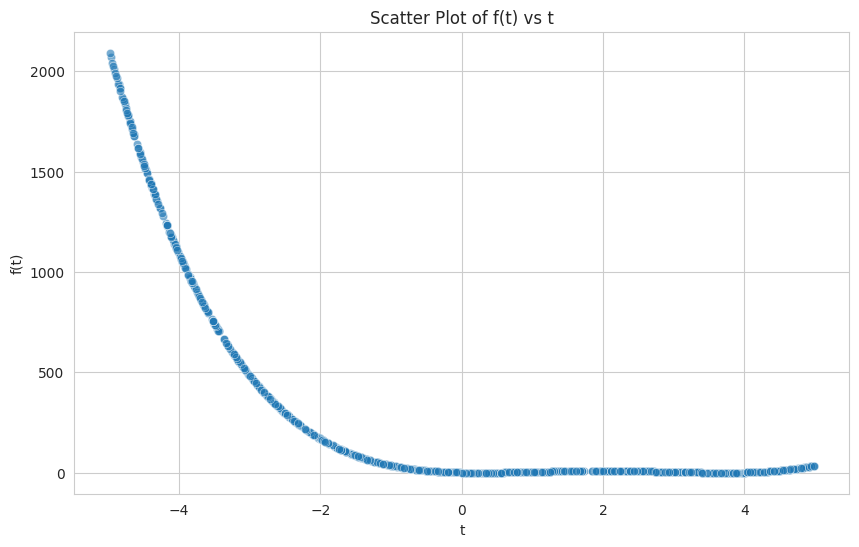

In [ ]:
# Visualizing the Data for Trend Identification

import matplotlib.pyplot as plt
import seaborn as sns

# Scatter Plot of f(t) vs t
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(x='t', y='f(t)', data=df2, alpha=0.6)
plt.title('Scatter Plot of f(t) vs t')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.show()


I have used the polynomial regression model because the scatter plot of f(t) versus clearly shows a non-linear, U-shaped relationship. The data does not follow a straight line instead, f(t) decreases significantly as t goes from negative values towards zero, and then increases again as t goes to positive values.



In [ ]:
# Polynomial Regression Model Training and Evaluation

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Prepare the data
X = df2[['t']]
y = df2['f(t)']

# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Apply Polynomial Features (degree 2 for a quadratic fit)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
# Train a Linear Regression model on the polynomial features
model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

In [ ]:
# Make predictions
y_pred = model.predict(X_test_poly)

In [ ]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [ ]:
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Squared Error (MSE): 23639.2856
Root Mean Squared Error (RMSE): 153.7507
R-squared (R2): 0.9083


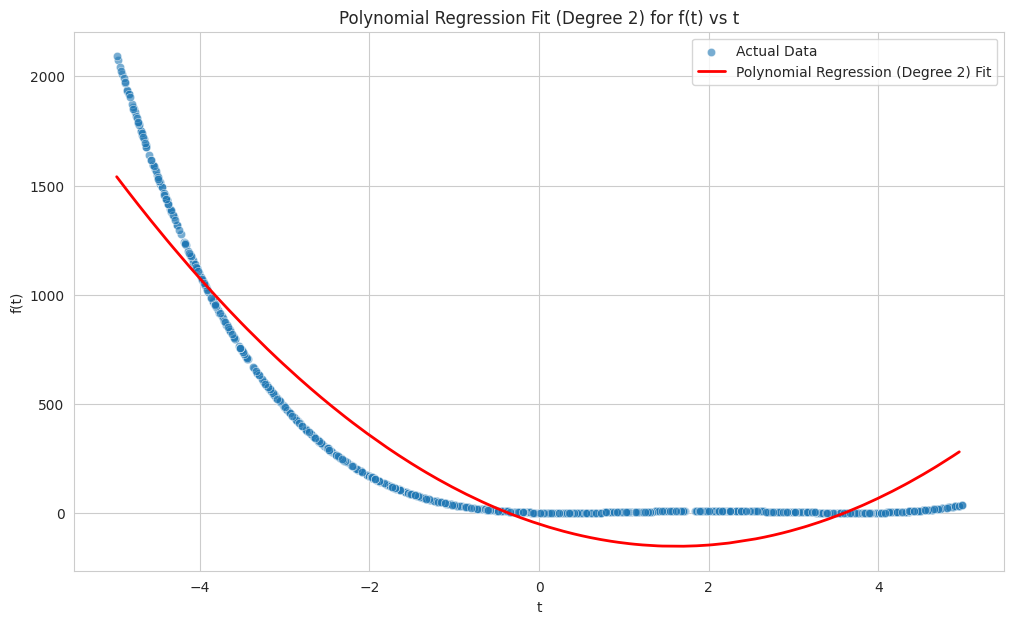

In [ ]:
# Visualizing the Polynomial Regression Fit and Trends
plt.figure(figsize=(12, 7))
sns.scatterplot(x='t', y='f(t)', data=df2, alpha=0.6, label='Actual Data')

# Sort the values for plotting the fitted line smoothly
sort_idx = np.argsort(X_test['t'].values)
X_test_sorted = X_test['t'].values[sort_idx]
y_pred_sorted = y_pred[sort_idx]

plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=2, label='Polynomial Regression (Degree 2) Fit')
plt.title('Polynomial Regression Fit (Degree 2) for f(t) vs t')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.legend()
plt.show()


Based on the polynomial regression model (degree 2), the underlying trend in the data appears to be **quadratic and symmetric around a minimum point**. As `t` decreases from this minimum point, `f(t)` increases exponentially, and similarly, as `t` increases from this minimum, `f(t)` also increases. The relationship clearly shows that `f(t)` is minimized when `t` is close to zero, and then it rapidly increases as `t` moves away from zero in either the positive or negative direction. This suggests a functional form potentially like $f(t) = a t^2 + b t + c$ or an exponential decay for both positive and negative values of t, which can be captured effectively by a polynomial model.